# Poynting ADCIG — a custom imaging condition via `register_gradient`

Angle-domain common-image gathers (ADCIGs) decompose the standard RTM image
at each subsurface point into contributions from different *reflection angles*.
This notebook builds an ADCIG via the `register_gradient` hook in SWEEP's
eager backend; the hook lets the user's fn access both the forward and the
adjoint wavefield at every timestep, so it can scatter contributions into the
right angle bin.

The Poynting-vector recipe (Yoon & Marfurt 2006):

1. Per timestep `t`, form the time derivative
   $s_p = \partial_t u_f$, $g_p = \partial_t u_b$.
2. Spatial gradients $\nabla u_f, \nabla u_b$ give the *Poynting vectors*
   $\mathbf S_s = s_p\,\nabla u_f$, $\mathbf S_g = g_p\,\nabla u_b$.
3. Reflection half-angle:
   $\alpha = \tfrac12 \arccos\!\bigl(\mathbf S_s\!\cdot\!\mathbf S_g / (|\mathbf S_s||\mathbf S_g|)\bigr)$.
4. Scatter the zero-lag contribution into the angle bin
   $\lfloor\alpha/\Delta\alpha\rfloor$.

Fitting this into `register_gradient`: a 4D angle gather (na, nz, nx) doesn't
fit the standard fn return shape (single model grid). We use the hook as a
*side-effect channel* — fn keeps `prev_uf` / `prev_ub` and the angle-bin
accumulator in a closure and scatter-adds every step. fn returns the usual
zero-lag contribution so `prop.imaging()` also gives a sensible standard RTM
image.

> See `14_custom_gradient.ipynb` for the basics of `register_gradient`.
> Eager backend only (`impl='eager'`). 36 shots → ≈ 6 min on a single GPU.

> **This notebook is about the custom-backward mechanism** — how to plug an
> arbitrary imaging condition into the eager backward via `register_gradient`,
> using the Poynting-vector ADCIG as the worked example.  For the **space-lag
> (subsurface-offset) ADCIG**, including the built-in CUDA `compute_adcig`
> toggle and 2D + 3D examples, see `22_adcig_space_lag.ipynb`.


## Imports + setup


In [1]:
import sys, pathlib
# Prepend worktree src/ so `import sweep` picks up this branch's code
_repo = pathlib.Path().resolve().parents[1]
if str(_repo / 'src') not in sys.path:
    sys.path.insert(0, str(_repo / 'src'))

import math
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

from sweep.equations import Acoustic
from sweep.propagator.torch import PropTorch
from sweep.signal import ricker

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)


device: cuda


## Setup — two-layer acoustic, RTM flow

shot positions (grid): [20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 105, 110, 115, 120, 125, 130, 135, 140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 190, 195]


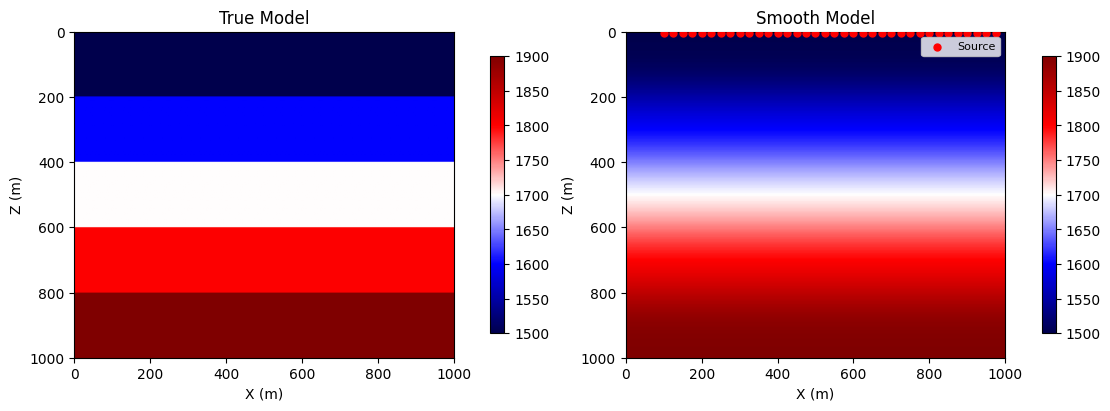

collected 36 shot records, each (1, 1500, 200, 1)


In [2]:
# Geometry / model patterned after the user's ADCIG_LAYER reference:
#   5 layers, 4 reflectors at z = 200/400/600/800 m
#   vp = 1500/1600/1700/1800/1900 m/s   (CFL = 1900*0.001/5 = 0.38, safe)
#   smooth background = Gaussian-smoothed true model (preserves the
#                       depth gradient, kills the sharp reflectors —
#                       residual = obs - syn ≈ reflected energy only).
from scipy.ndimage import gaussian_filter1d
import math

ad_shape  = (200, 200)        # nz, nx → 1000 × 1000 m at dh=5
ad_dh     = 5.0
ad_dt     = 0.001
ad_nt     = 1500
ad_freq   = 25.0
ad_delay  = 0.1
ad_amp    = 1000.0
ad_abcn   = 50
ad_order  = 8

# True model — 5 horizontal layers, reflectors at grid z = 40/80/120/160
vp_true_ad = np.full(ad_shape, 1500.0, dtype=np.float32)
vp_true_ad[ 40:, :] = 1600.0
vp_true_ad[ 80:, :] = 1700.0
vp_true_ad[120:, :] = 1800.0
vp_true_ad[160:, :] = 1900.0

# Smooth background — Gaussian smooth the TRUE model along depth.
# sigma in grid points (≈ 75 m, larger than one wavelength λ ≈ vp/f ≈ 68 m).
vp_smooth_ad = gaussian_filter1d(vp_true_ad, sigma=15, axis=0).astype(np.float32)

eq_ad   = Acoustic(spatial_order=ad_order, device=device)
prop_ad = PropTorch(eq_ad, shape=ad_shape, abcn=ad_abcn,
                    dh=ad_dh, dt=ad_dt, dev=device,
                    use_ckpt=False, impl='eager')

t_ad   = np.arange(ad_nt, dtype=np.float32) * ad_dt
wav_ad = (ad_amp * ricker(t_ad - ad_delay, f=ad_freq)).astype(np.float32)

# 36 shots — yml full density (source_start=20, source_end=199, step=5)
shot_x_grid = np.arange(20, 200, 5, dtype=np.int64)
print(f'shot positions (grid): {shot_x_grid.tolist()}')

# Receivers — full surface line, every grid point, depth=1
rec_xa = np.arange(0, ad_shape[1], dtype=np.int64)
rec_ad = np.stack([rec_xa, np.full_like(rec_xa, 1)], axis=1)[None]

# Visualize true / smooth side-by-side (matches the reference layout)
extent_m = [0, ad_shape[1] * ad_dh, ad_shape[0] * ad_dh, 0]
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for ax, m, name in zip(axes, [vp_true_ad, vp_smooth_ad], ['True Model', 'Smooth Model']):
    im = ax.imshow(m, cmap='seismic', vmin=1500, vmax=1900, aspect='auto', extent=extent_m)
    ax.set_title(name); ax.set_xlabel('X (m)'); ax.set_ylabel('Z (m)')
    fig.colorbar(im, ax=ax, shrink=0.85)
axes[1].scatter([int(sx) * ad_dh for sx in shot_x_grid],
                 [ad_dh] * len(shot_x_grid),
                 c='red', s=25, label='Source', zorder=5)
axes[1].legend(loc='upper right', fontsize=8)
plt.show()

# Pre-forward observed records per shot on the TRUE model
vp_true_torch = torch.tensor(vp_true_ad, device=device)
shot_obs = []
for sx in shot_x_grid:
    src_one = np.array([[int(sx), 1]], dtype=np.int64)
    with torch.no_grad():
        shot_obs.append(prop_ad(wav_ad, src_one, rec_ad, models=[vp_true_torch]))
print(f'collected {len(shot_obs)} shot records, each {tuple(shot_obs[0].shape)}')

## ADCIG via `register_gradient` + closure

Time derivatives via consecutive snapshots, Poynting vector dot-product for
the angle, scatter-add into `(na, nz, nx)`. Because hooks fire in reverse
time, the closure's `prev` slot holds the *next* physical timestep — this
only flips the sign of $s_p$, $g_p$, which doesn't affect the angle
(sign-invariant) or $s_p\,g_p$ (sign-symmetric).


## Quick QC — observed vs synthetic shot record

### What `observed` does inside `prop.imaging(...)`

`prop.imaging()` has no explicit loss — internally it calls
`record.backward(gradient=adj_src)` directly, where `adj_src` *is* what would
have come out of differentiating some loss against `record`. Passing
`observed=obs` makes `adj_src = pred − obs`, which is exactly
$\partial L / \partial \text{pred}$ for the standard L2 FWI misfit
$L = \tfrac12\,\lVert\text{pred} - \text{obs}\rVert^2$.

So with `observed=obs`, `imaging()` runs a real RTM:

- forward on the SMOOTH background model → `pred` (direct + refraction, no
  sharp reflections)
- `adj_src = pred − obs` carries the **reflection energy** the smooth model
  failed to predict
- the reverse pass back-propagates this residual through the wave equation;
  the hook sees the resulting adjoint wavefield at every timestep and our
  ADCIG fn scatters contributions into angle bins

If we called `prop.imaging(...)` without `observed`, `adj_src` would default
to `pred` itself — a zero-lag autocorrelation of the forward record onto
itself, giving no useful image (no data residual to migrate). See
`14_custom_gradient.ipynb` §4 for the full table of `imaging()` argument
options.

### What we plot below

Sanity-check the residual is actually non-trivial — pick one shot, compare:

1. `obs` — record from the TRUE 5-layer model (direct wave + reflections)
2. `syn` — record from the SMOOTH model (mostly just the direct wave)
3. `obs − syn` — the `adj_src` that gets injected at receivers in `imaging()`


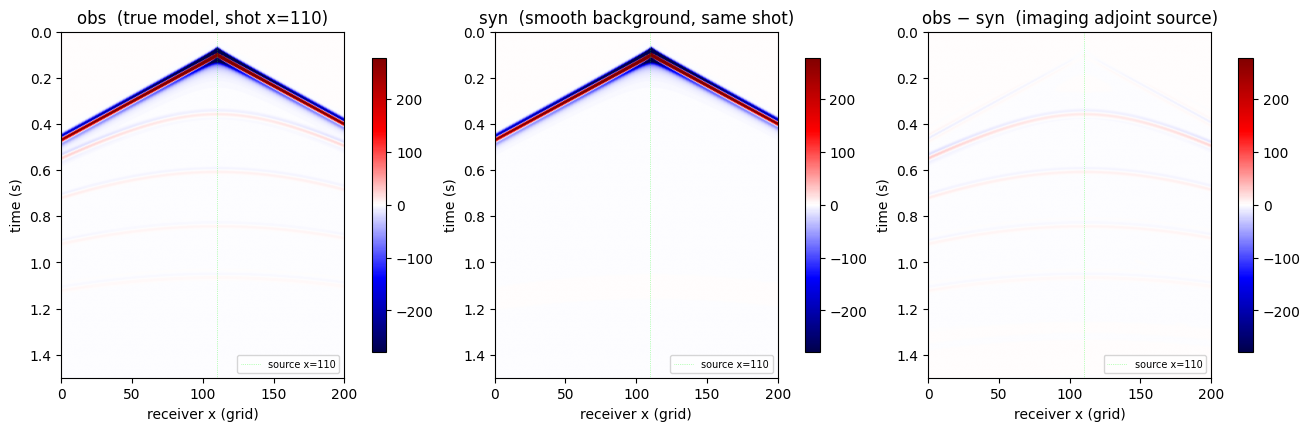

obs |max|=4.388e+03   syn |max|=4.384e+03   residual |max|=2.825e+01
residual norm / obs norm = 0.029   (this energy is what feeds the imaging condition)


In [3]:
# Forward one synthetic on the SMOOTH background for the middle shot
qc_k  = len(shot_x_grid) // 2
qc_sx = int(shot_x_grid[qc_k])
qc_src = np.array([[qc_sx, 1]], dtype=np.int64)
with torch.no_grad():
    qc_syn = prop_ad(wav_ad, qc_src, rec_ad,
                      models=[torch.tensor(vp_smooth_ad, device=device)])
qc_obs = shot_obs[qc_k]
qc_res = qc_obs - qc_syn

# Records have shape (1, nt, nrec, 1) — squeeze to (nt, nrec)
obs_np = qc_obs[0, :, :, 0].cpu().numpy()
syn_np = qc_syn[0, :, :, 0].cpu().numpy()
res_np = qc_res[0, :, :, 0].cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), constrained_layout=True)
vlim = np.percentile(np.abs(obs_np), 99) or 1.0
for ax, data, name in zip(axes,
                            [obs_np, syn_np, res_np],
                            [f'obs  (true model, shot x={qc_sx})',
                             f'syn  (smooth background, same shot)',
                             'obs − syn  (imaging adjoint source)']):
    im = ax.imshow(data, cmap='seismic', vmin=-vlim, vmax=vlim,
                    aspect='auto',
                    extent=[0, ad_shape[1], ad_nt * ad_dt, 0])
    ax.axvline(qc_sx, color='lime', lw=0.5, ls=':', alpha=0.5, label=f'source x={qc_sx}')
    ax.set_title(name); ax.set_xlabel('receiver x (grid)'); ax.set_ylabel('time (s)')
    ax.legend(fontsize=7, loc='lower right')
    fig.colorbar(im, ax=ax, shrink=0.85)
plt.show()

print(f'obs |max|={np.abs(obs_np).max():.3e}   syn |max|={np.abs(syn_np).max():.3e}   '
      f'residual |max|={np.abs(res_np).max():.3e}')
print(f'residual norm / obs norm = {np.linalg.norm(res_np) / np.linalg.norm(obs_np):.3f}   '
      f'(this energy is what feeds the imaging condition)')

In [4]:
import math

NA = 90                       # angle bins, 0..π/2
EPS_ADCIG = 1e-22
USE_TIME_DERIV_CONTRIB = False   # True  → JAX-original sp*gp (high-freq weighted)
                                 # False → standard zero-lag  forward['h1']*adjoint['h1']  (cleaner)

def grad_xz_t(field, h):
    dx = torch.zeros_like(field); dz = torch.zeros_like(field)
    dx[..., :, 1:-1] = (field[..., :, 2:] - field[..., :, :-2]) / (2 * h)
    dz[..., 1:-1, :] = (field[..., 2:, :] - field[..., :-2, :]) / (2 * h)
    return dx, dz

class ADCIGState:
    def __init__(self):
        self.prev_uf = None; self.prev_ub = None
        self.num = None; self.den = None
        self.calls = 0
    def reset_per_shot(self):
        self.prev_uf = None; self.prev_ub = None

state = ADCIGState()

def adcig_fn(forward, adjoint, models, dt, dh):
    state.calls += 1
    uf = forward['h1']; ub = adjoint['h1']
    if state.num is None:
        _, _, H, W = uf.shape
        state.num = torch.zeros((NA, H, W), dtype=uf.dtype, device=uf.device)
        state.den = torch.zeros((H, W),     dtype=uf.dtype, device=uf.device)
    if state.prev_uf is None:
        state.prev_uf = uf.detach().clone()
        state.prev_ub = ub.detach().clone()
        return torch.zeros_like(uf)

    sp = uf - state.prev_uf
    gp = ub - state.prev_ub
    svx, svz = grad_xz_t(uf, dh)
    gvx, gvz = grad_xz_t(ub, dh)
    Ssx, Ssz = sp * svx, sp * svz
    Sgx, Sgz = gp * gvx, gp * gvz
    b1  = Ssx * Ssx + Ssz * Ssz
    b2  = Sgx * Sgx + Sgz * Sgz
    dot = Ssx * Sgx + Ssz * Sgz
    cos_a = torch.clamp(dot / torch.sqrt(b1 * b2 + EPS_ADCIG), -1.0, 1.0)
    alpha = 0.5 * torch.arccos(cos_a)
    da    = math.pi / (2.0 * NA)
    ia    = torch.clamp(torch.trunc(alpha / da).long(), 0, NA - 1)

    # Validity mask — kill spurious α=45° from b1*b2≈0 cells
    poynt_mag = torch.sqrt(b1 * b2)
    thresh = poynt_mag.max() * 1e-4
    valid = (poynt_mag > thresh)[0, 0].float()

    # Contribution choice: standard zero-lag forward['h1'] * adjoint['h1']
    # is cleaner than time-derivative sp*gp (which weights high frequencies and adds noise).
    if USE_TIME_DERIV_CONTRIB:
        contrib_raw = (sp * gp)[0, 0]
    else:
        contrib_raw = (uf * ub)[0, 0]
    contrib = contrib_raw * valid
    ia2d = ia[0, 0]
    H, W = contrib.shape
    lin  = ia2d.view(-1) * (H * W) + torch.arange(H * W, device=uf.device)
    state.num.view(-1).scatter_add_(0, lin, contrib.view(-1).detach())
    state.den.add_(((ub[0, 0]) ** 2).detach())   # standard illumination ∫|ub|² dt

    state.prev_uf = uf.detach().clone()
    state.prev_ub = ub.detach().clone()
    return contrib.view_as(uf)

prop_ad.clear_gradients()
prop_ad.register_gradient('vp', adcig_fn, mode='imaging')

vp_smooth_torch = torch.tensor(vp_smooth_ad, device=device)
vp_image_stack = None
for k, sx in enumerate(shot_x_grid):
    state.reset_per_shot()
    src_one = np.array([[int(sx), 1]], dtype=np.int64)
    imgs = prop_ad.imaging(wav_ad, src_one, rec_ad,
                            models=[vp_smooth_torch], observed=shot_obs[k])
    if vp_image_stack is None:
        vp_image_stack = imgs['vp'].detach().clone()
    else:
        vp_image_stack += imgs['vp'].detach()
    del imgs
    if (k+1) % 3 == 0 or k+1 == len(shot_x_grid):
        print(f'  shot {k+1}/{len(shot_x_grid)} done')

vp_image = vp_image_stack.cpu().numpy()
num      = state.num.cpu().numpy()
den      = state.den.cpu().numpy()
print(f'\nTotal fn calls: {state.calls}  (USE_TIME_DERIV_CONTRIB={USE_TIME_DERIV_CONTRIB})')
print(f'angle gather (NA, H_rt, W_rt): {num.shape}')
print(f'stacked image: {vp_image.shape}  norm={np.linalg.norm(vp_image):.3e}')



  shot 3/36 done


  shot 6/36 done


  shot 9/36 done


  shot 12/36 done


  shot 15/36 done


...

  shot 24/36 done


  shot 27/36 done


  shot 30/36 done


  shot 33/36 done


  shot 36/36 done

Total fn calls: 54000  (USE_TIME_DERIV_CONTRIB=False)
angle gather (NA, H_rt, W_rt): (90, 308, 308)
stacked image: (200, 200)  norm=2.283e+09


## Visualise — standard image, angle gather, illumination


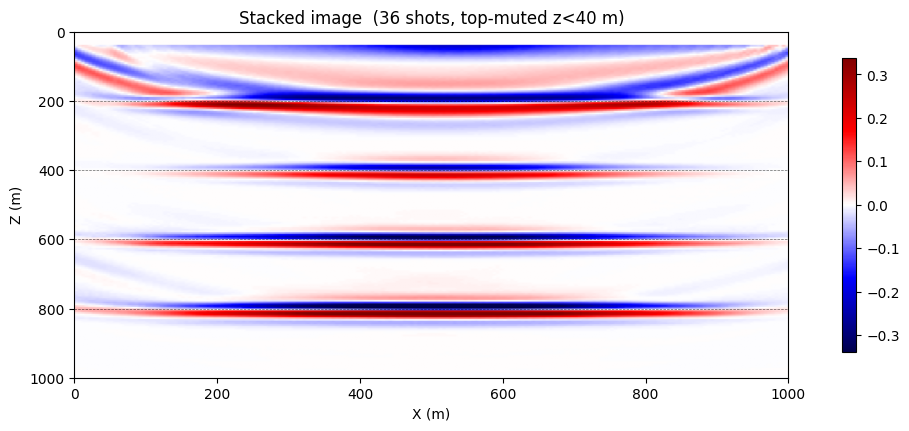

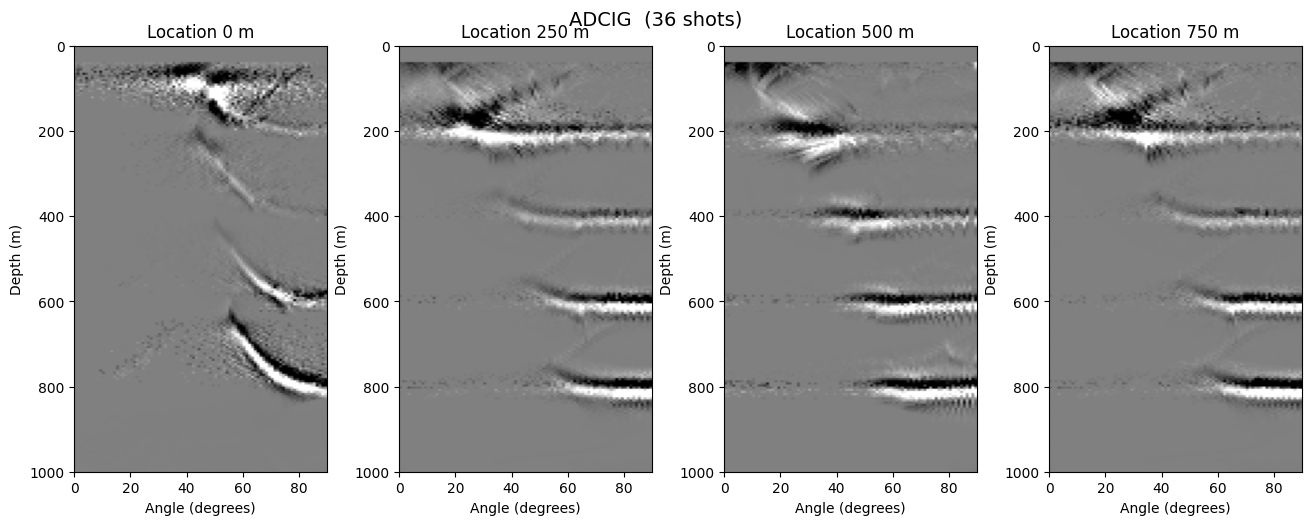

In [5]:
# Crop runtime-padded gather + illumination-normalize
off_z = (num.shape[1] - ad_shape[0]) // 2
off_x = (num.shape[2] - ad_shape[1]) // 2
num_m = num[:, off_z:off_z + ad_shape[0], off_x:off_x + ad_shape[1]]
den_m = den[   off_z:off_z + ad_shape[0], off_x:off_x + ad_shape[1]]
img_norm    = vp_image / (den_m + 1e-30)
gather_norm = num_m   / (den_m[None] + 1e-30)

# Light top mute (skip the source/receiver line)
MUTE = 8
img_norm   [:MUTE, :]    = 0
gather_norm[:, :MUTE, :] = 0
REFL_Z_M = [200, 400, 600, 800]

# Stacked image preview
fig0, ax0 = plt.subplots(1, 1, figsize=(9, 4.2), constrained_layout=True)
vlim = np.percentile(np.abs(img_norm), 99) or 1.0
im0 = ax0.imshow(img_norm, cmap='seismic', vmin=-vlim, vmax=vlim, aspect='auto',
                  extent=[0, ad_shape[1]*ad_dh, ad_shape[0]*ad_dh, 0])
for zm in REFL_Z_M:
    ax0.axhline(zm, color='k', lw=0.5, ls='--', alpha=0.6)
ax0.set_title(f'Stacked image  ({len(shot_x_grid)} shots, top-muted z<{MUTE * ad_dh:.0f} m)')
ax0.set_xlabel('X (m)'); ax0.set_ylabel('Z (m)')
fig0.colorbar(im0, ax=ax0, shrink=0.85)
plt.show()

# ADCIG panel — locations 0 / 250 / 500 / 750 m, grayscale, depth in metres
x_loc_m = [0, 250, 500, 750]
x_cols  = [int(round(xm / ad_dh)) for xm in x_loc_m]

fig, axes = plt.subplots(1, len(x_cols), figsize=(13, 5), constrained_layout=True)
for ax, xc, xm in zip(axes, x_cols, x_loc_m):
    g = gather_norm[:, :, xc]   # (NA, nz)
    vl = np.percentile(np.abs(g), 98) or 1.0
    h  = ax.imshow(g.T, cmap='gray', vmin=-vl, vmax=vl, aspect='auto',
                    extent=[0, 90, ad_shape[0] * ad_dh, 0])
    ax.set_title(f'Location {xm} m')
    ax.set_xlabel('Angle (degrees)'); ax.set_ylabel('Depth (m)')
plt.suptitle(f'ADCIG  ({len(shot_x_grid)} shots)', fontsize=14, y=1.02)
plt.show()